# 1. Problem Statement

The bank conducts marketing campaigns through phone calls to promote term deposits. However, many calls do not result in a subscription, leading to wasted time and resources. To improve efficiency, the bank needs to identify high-potential customers and determine the best timing for successful campaigns.

**Stakeholder**

The bank aims to improve the success rate of its marketing campaigns and optimize resource allocation.

**Key Challenges**

Many customers contacted do not subscribe, leading to high costs and low conversion rates.
Inefficient targeting results in wasted effort and lower profitability.
The bank lacks insights into when campaigns are most effective.

**Goals & Key Questions**

1️⃣ Optimize customer targeting

How can we predict which customers will subscribe?

Goal: Build a model to identify high-potential customers and improve marketing efficiency.

2️⃣ Improve campaign effectiveness

Which customer should we target so we can improve marketing efficiency?

Goal: Use demographic bank client data to tailor marketing strategies.

3️⃣ Find the best campaign timing

When is the best time of the year for a successful campaign to improve marketing efficiency?

Goal: Analyze seasonal trends to determine the most effective months and days for outreach.

**By addressing these questions, the bank can reduce unnecessary calls, lower costs, and increase conversion rates. 🚀**

**Metric Evaluation**
| **ACTUAL**                         | **Predicted: No (0)**                 | **Predicted: Yes (1)**                |
|-------------------------------------|--------------------------------------|--------------------------------------|
| **Did not subscribe (0)**          | **TRUE NEGATIVE (TN)** <br> Model predicts the client **did not subscribe**, and they actually didn’t. | **FALSE POSITIVE (FP)** <br> Model predicts the client **subscribed**, but they actually didn’t. |
| **Subscribed (1)**                 | **FALSE NEGATIVE (FN)** <br> Model predicts the client **did not subscribe**, but they actually did. | **TRUE POSITIVE (TP)** <br> Model predicts the client **subscribed**, and they actually did. |


# 2. Data Understanding

Dataset source: https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset 

| Feature       | Description                                      | Type       | Attribute                                |
|--------------|------------------------------------------------|-----------|------------------------------------------|
| age          | Age of the client                              | Numeric   | Bank client data                        |
| job          | Type of job                                   | Categorical | Bank client data                        |
| marital      | Marital status                               | Categorical | Bank client data                        |
| education    | Education level                              | Categorical | Bank client data                        |
| default      | Has credit in default?                       | Categorical | Bank client data                        |
| housing      | Has housing loan?                            | Categorical | Bank client data                        |
| loan         | Has personal loan?                           | Categorical | Bank client data                        |
| contact      | Contact communication type                   | Categorical | The last contact of current campaign |
| month        | Last contact month of the year               | Categorical | The last contact of current campaign |
| day_of_week  | Last contact day of the week                | Categorical | The last contact of current campaign |
| duration     | Last contact duration (seconds)             | Numeric   | The last contact of current campaign |
| campaign     | Number of contacts during this campaign     | Numeric   | The last contact of current campaign |
| pdays        | Days since last contact (999 = never contacted) | Numeric   | Data from the previous campaign |
| previous     | Number of contacts before this campaign     | Numeric   | Data from the previous campaign |
| poutcome     | Outcome of previous campaign                 | Categorical | Data from the previous campaign |
| emp.var.rate | Employment variation rate - quarterly indicator | Numeric   | Social economic context |
| cons.price.idx | Consumer price index - monthly indicator      | Numeric   | Social economic context |
| cons.conf.idx | Consumer confidence index - monthly indicator  | Numeric   | Social economic context |
| euribor3m    | European Interbank Offered Rate 3-month rate - daily indicator          | Numeric   | Social economic context |
| nr.employed  | Number of employees                         | Numeric   | Social economic context |
| y            | Client subscribed to term deposit?         | Binary    | Output variables (desired target) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px

In [2]:
ori = pd.read_csv("bank-additional-full.csv", sep=",")
df = ori.copy()
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [3]:
display(df.describe(), df.describe(include=object))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.019010
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.178074
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4964.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.000000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


# Data Cleaning

> ## Missing Value

<Axes: >

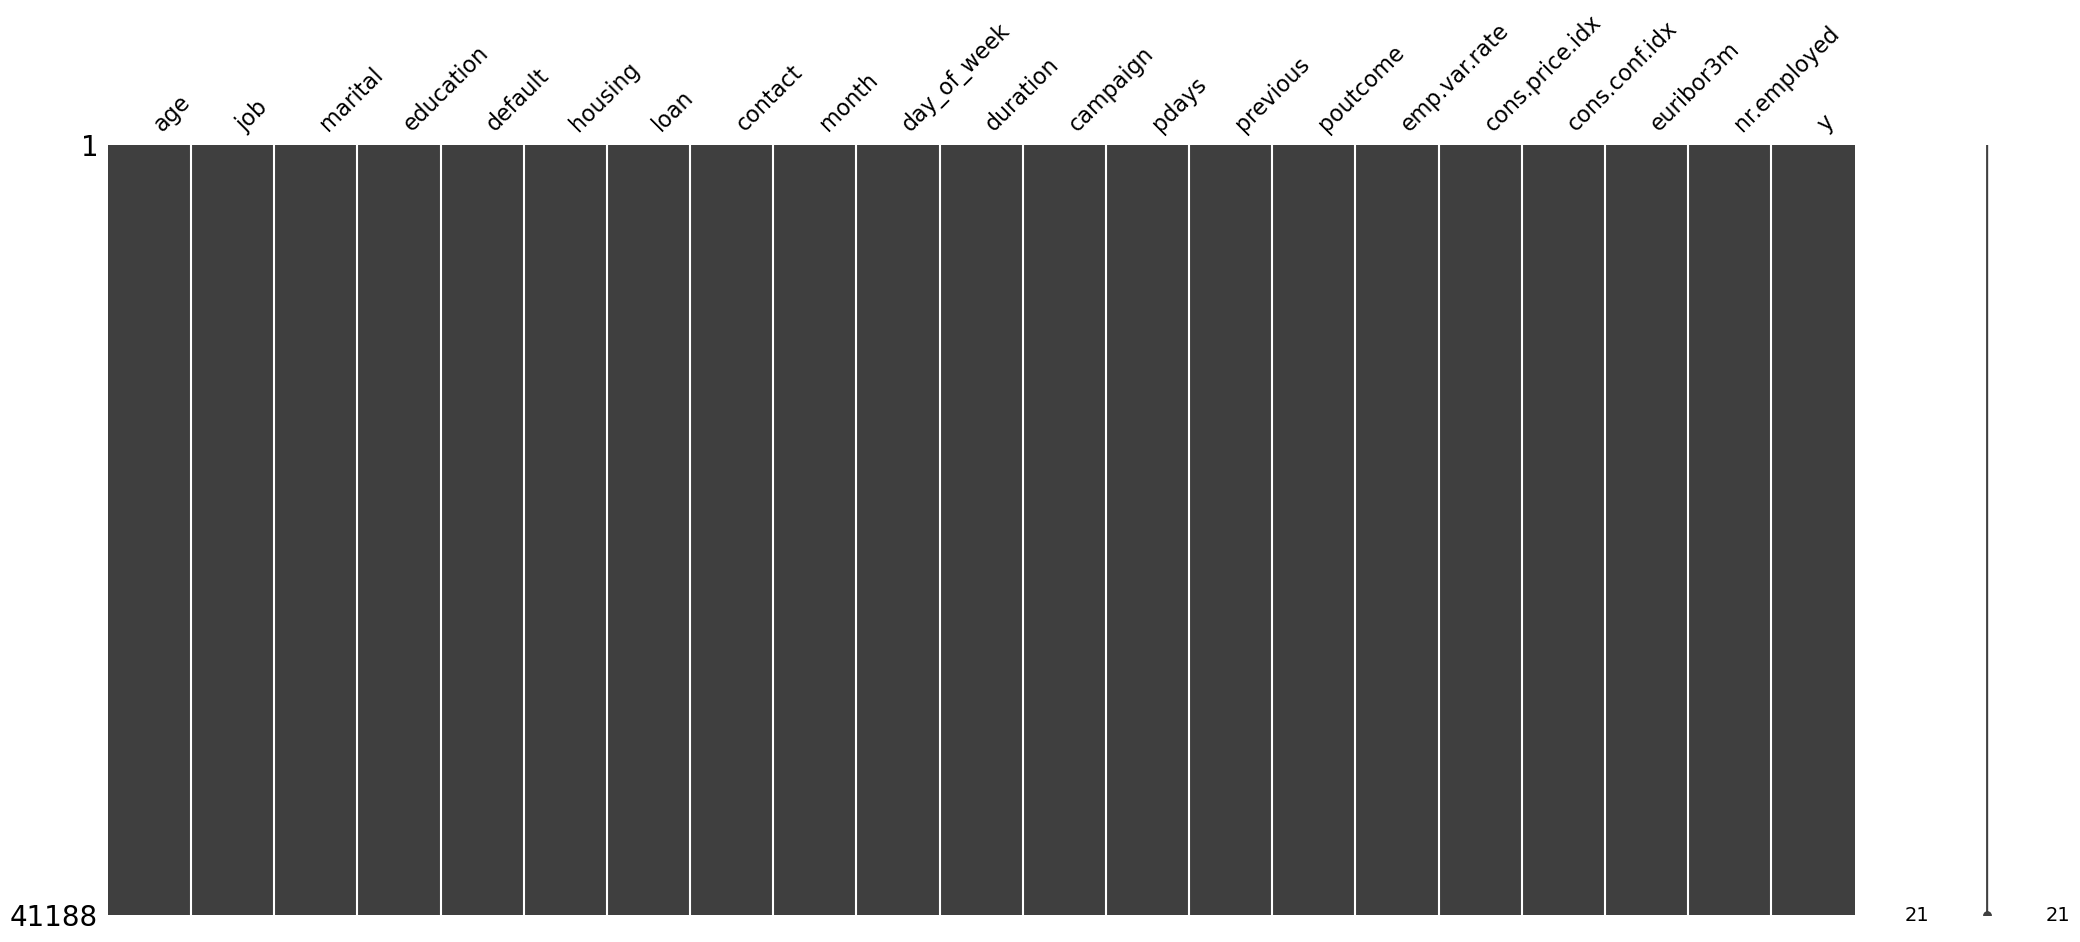

In [4]:
import missingno as msno 
msno.matrix(df)

In [5]:
df.isnull().sum().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

>## Duplicate Data

In [7]:
dupl=df.duplicated().sum()
print("Number of duplicate rows:", dupl)

Number of duplicate rows: 12


In [8]:
dupl_list = df[df.duplicated(subset=['age','job','marital','education','default','housing','loan','contact','month','day_of_week',
                               'duration','campaign','pdays','previous','poutcome','emp.var.rate','cons.price.idx','cons.conf.idx',
                              'euribor3m','nr.employed','y'], keep=False)]
display(dupl_list)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228,no


In [9]:
df.drop_duplicates()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4964,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4964,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4964,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4964,yes


# 3. Exploratory Data Analysis

>## Values Distribution in Numerical Columns

<Figure size 1500x1000 with 0 Axes>

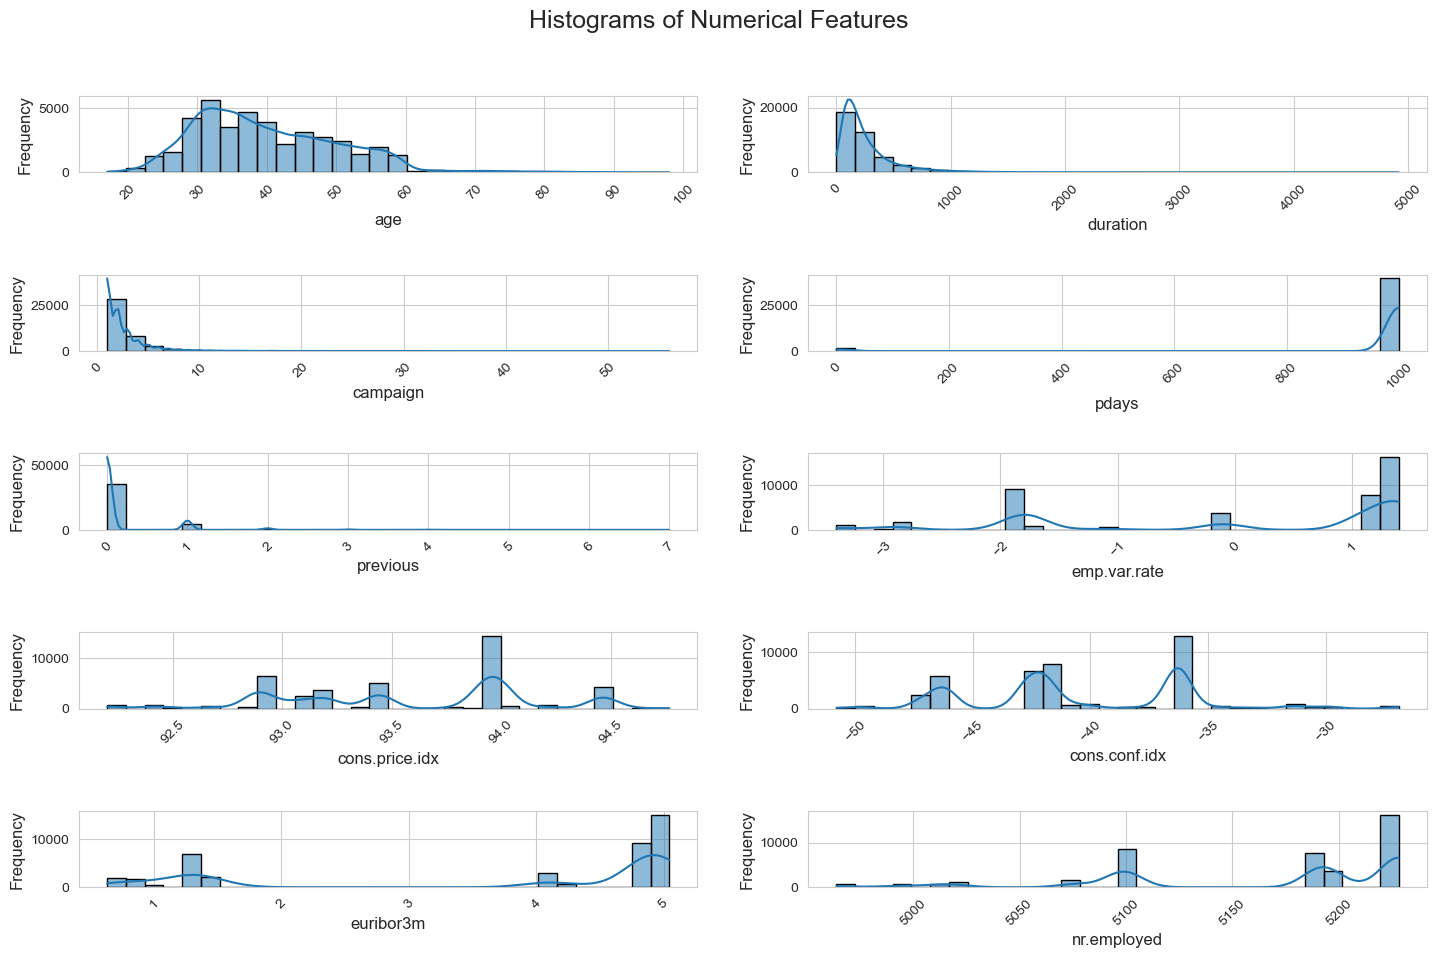

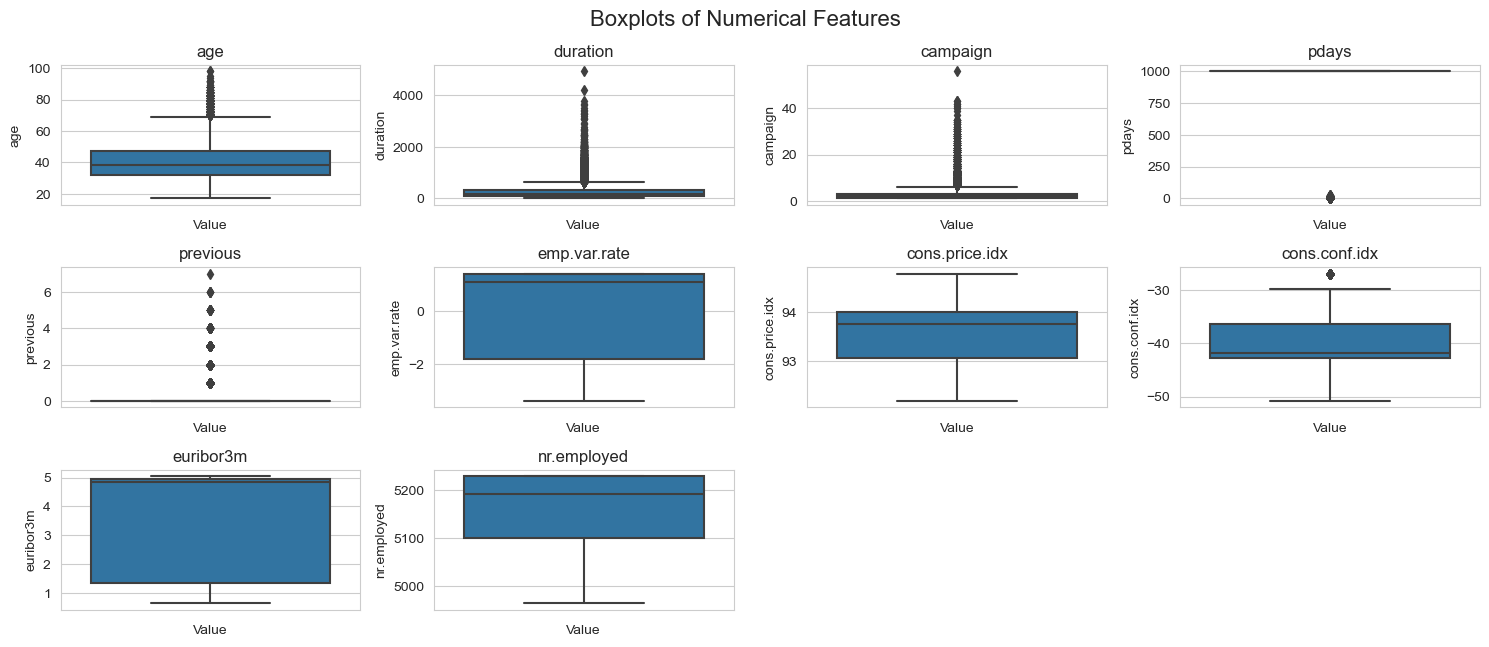

In [10]:
# Selecting numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Set plot style
sns.set_style("whitegrid")

# Create histograms for numerical columns
plt.figure(figsize=(15, 10))  
cols_per_row = 2  
num_cols = len(numerical_cols)
rows = (num_cols // cols_per_row) + (num_cols % cols_per_row > 0)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, ax=axes[i], kde=True, edgecolor='black')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Frequency", fontsize=12)
    axes[i].tick_params(axis='x', labelrotation=45, labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Histograms of Numerical Features", fontsize=18)
plt.tight_layout(pad=3.0)
plt.show()

>## Data Cardinalities

In [11]:
# Define categorical columns
categorical_columns = ["job", "marital", "education", "default", "housing", "loan", 
                        "contact", "month", "day_of_week", "poutcome", "y"]

# Ensure Pandas does not truncate output
pd.set_option('display.max_colwidth', None)

# Create an empty list to store data
unique_values_data = []

# Loop through categorical columns and get unique values
for col in categorical_columns:
    unique_values = ", ".join(df[col].astype(str).unique())
    unique_values_data.append([col, unique_values])

# Create DataFrame
df_unique_values = pd.DataFrame(unique_values_data, columns=["Feature", "Unique Values"])

# Display DataFrame
df_unique_values

,Feature,Unique Values
0,job,"housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student"
1,marital,"married, single, divorced, unknown"
2,education,"basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate"
3,default,"no, unknown, yes"
4,housing,"no, yes, unknown"
5,loan,"no, yes, unknown"
6,contact,"telephone, cellular"
7,month,"may, jun, jul, aug, oct, nov, dec, mar, apr, sep"
8,day_of_week,"mon, tue, wed, thu, fri"
9,poutcome,"nonexistent, failure, success"


In [12]:
# Loop through categorical columns and print value counts
for col in categorical_columns:
    print(f"{col.capitalize()}:\n{df[col].value_counts()}\n" + "-"*40)

Job:
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: job, dtype: int64
----------------------------------------
Marital:
married     24928
single      11568
divorced     4612
unknown        80
Name: marital, dtype: int64
----------------------------------------
Education:
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: education, dtype: int64
----------------------------------------
Default:
no         32588
unknown     8597
yes            3
Name: default, dtype: int64
----------------------------------------
Housing:
yes        21576
no         18622
unknown      990
N

>## Distribution of Unique Values in Categorical Columns

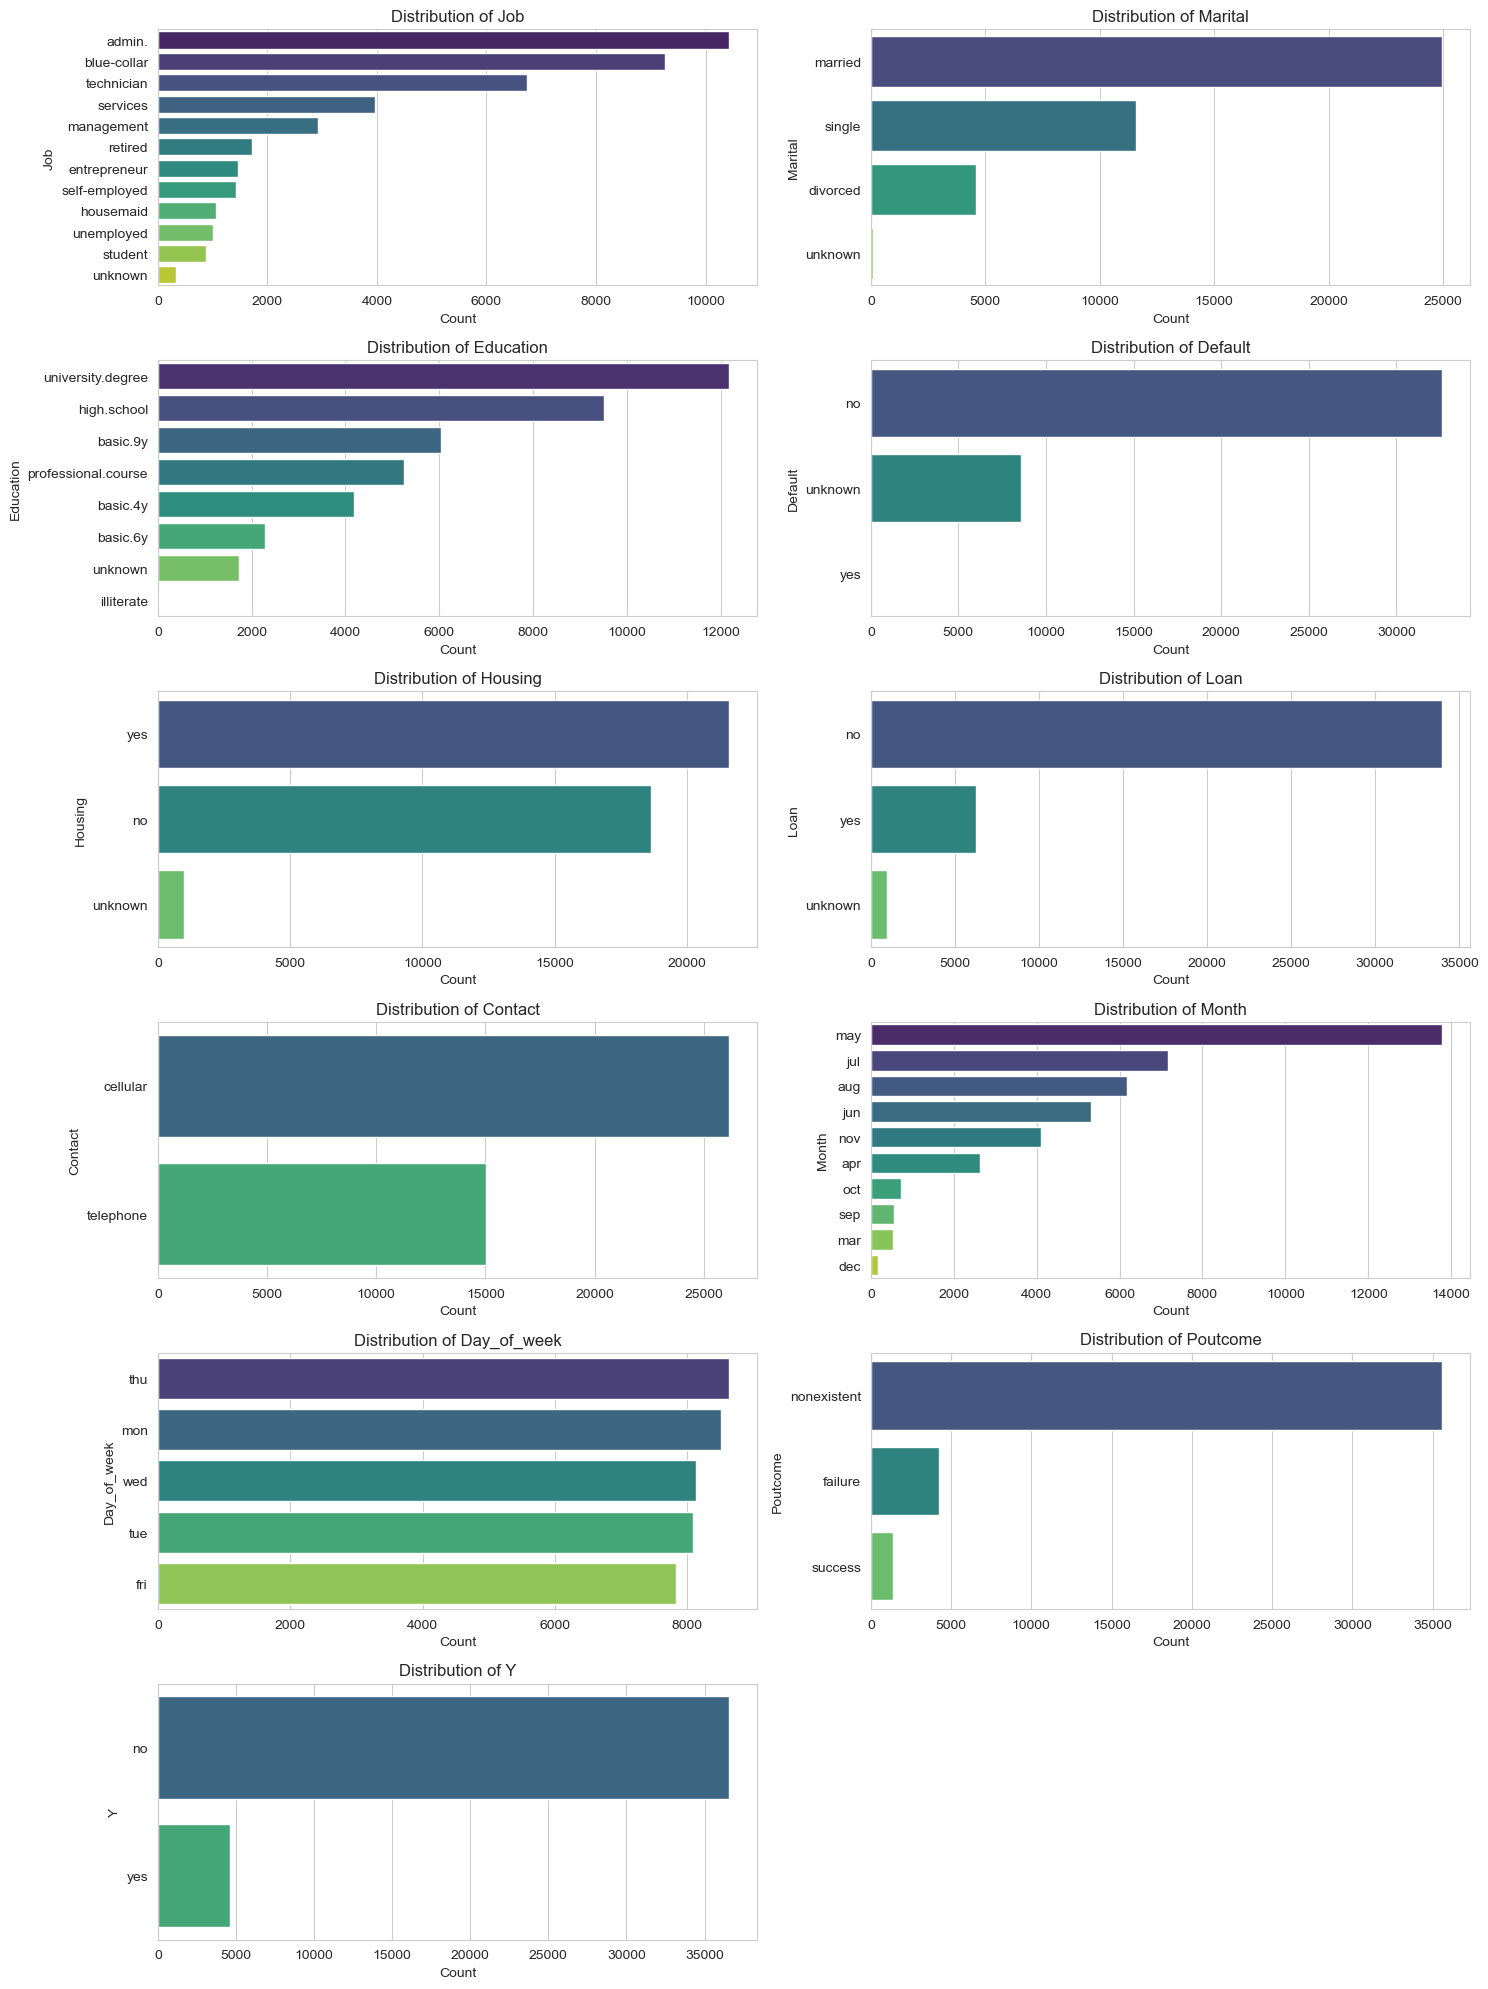

In [13]:
# Set figure size
plt.figure(figsize=(15, 20))

# Loop through categorical columns and create subplots
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(len(categorical_columns) // 2 + 1, 2, i)
    sns.countplot(y=df[col], palette="viridis", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel("Count")
    plt.ylabel(col.capitalize())

# Adjust layout
plt.tight_layout()
plt.show()

>## Relationships between Categorical Variables and Subscription 

<Axes: xlabel='education'>

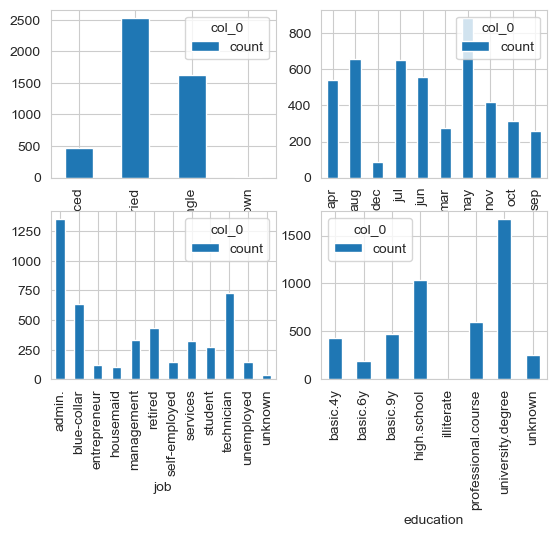

In [14]:
bank_yes = df[df['y']=='yes']


df1 = pd.crosstab(index = bank_yes["marital"],columns="count")    
df2 = pd.crosstab(index = bank_yes["month"],columns="count")  
df3= pd.crosstab(index = bank_yes["job"],columns="count") 
df4=pd.crosstab(index = bank_yes["education"],columns="count")

fig, axes = plt.subplots(nrows=2, ncols=2)
df1.plot.bar(ax=axes[0,0])
df2.plot.bar(ax=axes[0,1])
df3.plot.bar(ax=axes[1,0])
df4.plot.bar(ax=axes[1,1]) 

Insights:

- Married leads have made high deposits followed by single
- There were much deposist made during may month as it is the start of bank period
- Leads who work in administrative position made deposits followed by technicians and blue collar employees
- Leads who had atleast university degree had made the deposits followed by highschool

> ## Relationships between Numerical Variables and Subscription
Which features have the strongest correlation with deposit subscription (y)?

In [15]:
df = pd.read_csv("bank-additional-full.csv", sep=",") 
df_numeric = df.select_dtypes(include=['number'])
df.head() 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [16]:
# Create numeric target variable where 'yes' = 1 and 'no' = 0
df_numeric['y_num'] = (df['y'] == 'yes').astype(int)
df_numeric.head()



,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_num
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191,0


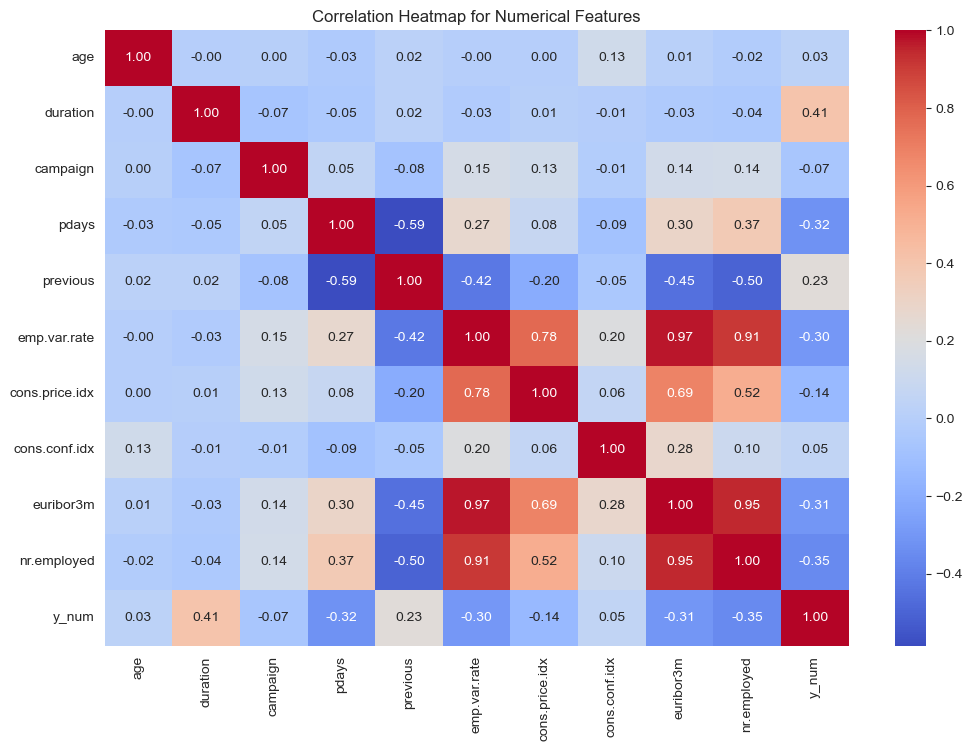

In [17]:
# Heatmap for numerical correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Numerical Features")
plt.show()


Insights:

- The indicators have correlation among themselves
- Number of employees rate is highly correlated with employee variation rate
- Consumer price index is highly correlated with bank interest rate( higher the price index, higher the interest rate)
- Employee variation rate also correlates with the bank interest rates

Relationship between Numerical Variables and Subscription 
- Positive correlation: duration (0.41), previous (0.23), cons.conf.idx (0.05), age (0.03)
- Negative correlation: campaign (-0.07), cons.price.idx (-0.14), emp.var.rate (-0.30), euribor3m (-0.31), pdays (-0.32), nr.employed (-0.35) 

Insight:

Duration has the strongest correlation with subscription. But in the machine learning model, we can not use the duration. The duration feature is not available at prediction time because it is recorded after the calls ends. Including it in the model would introduce data leakage, as it provides information that wouldn't be available when making predictions in practice. 

>## Outlier

C:\Users\nde\AppData\Local\Temp\ipykernel_14152\1296576524.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


Text(0.5, 1.0, 'No of employees')

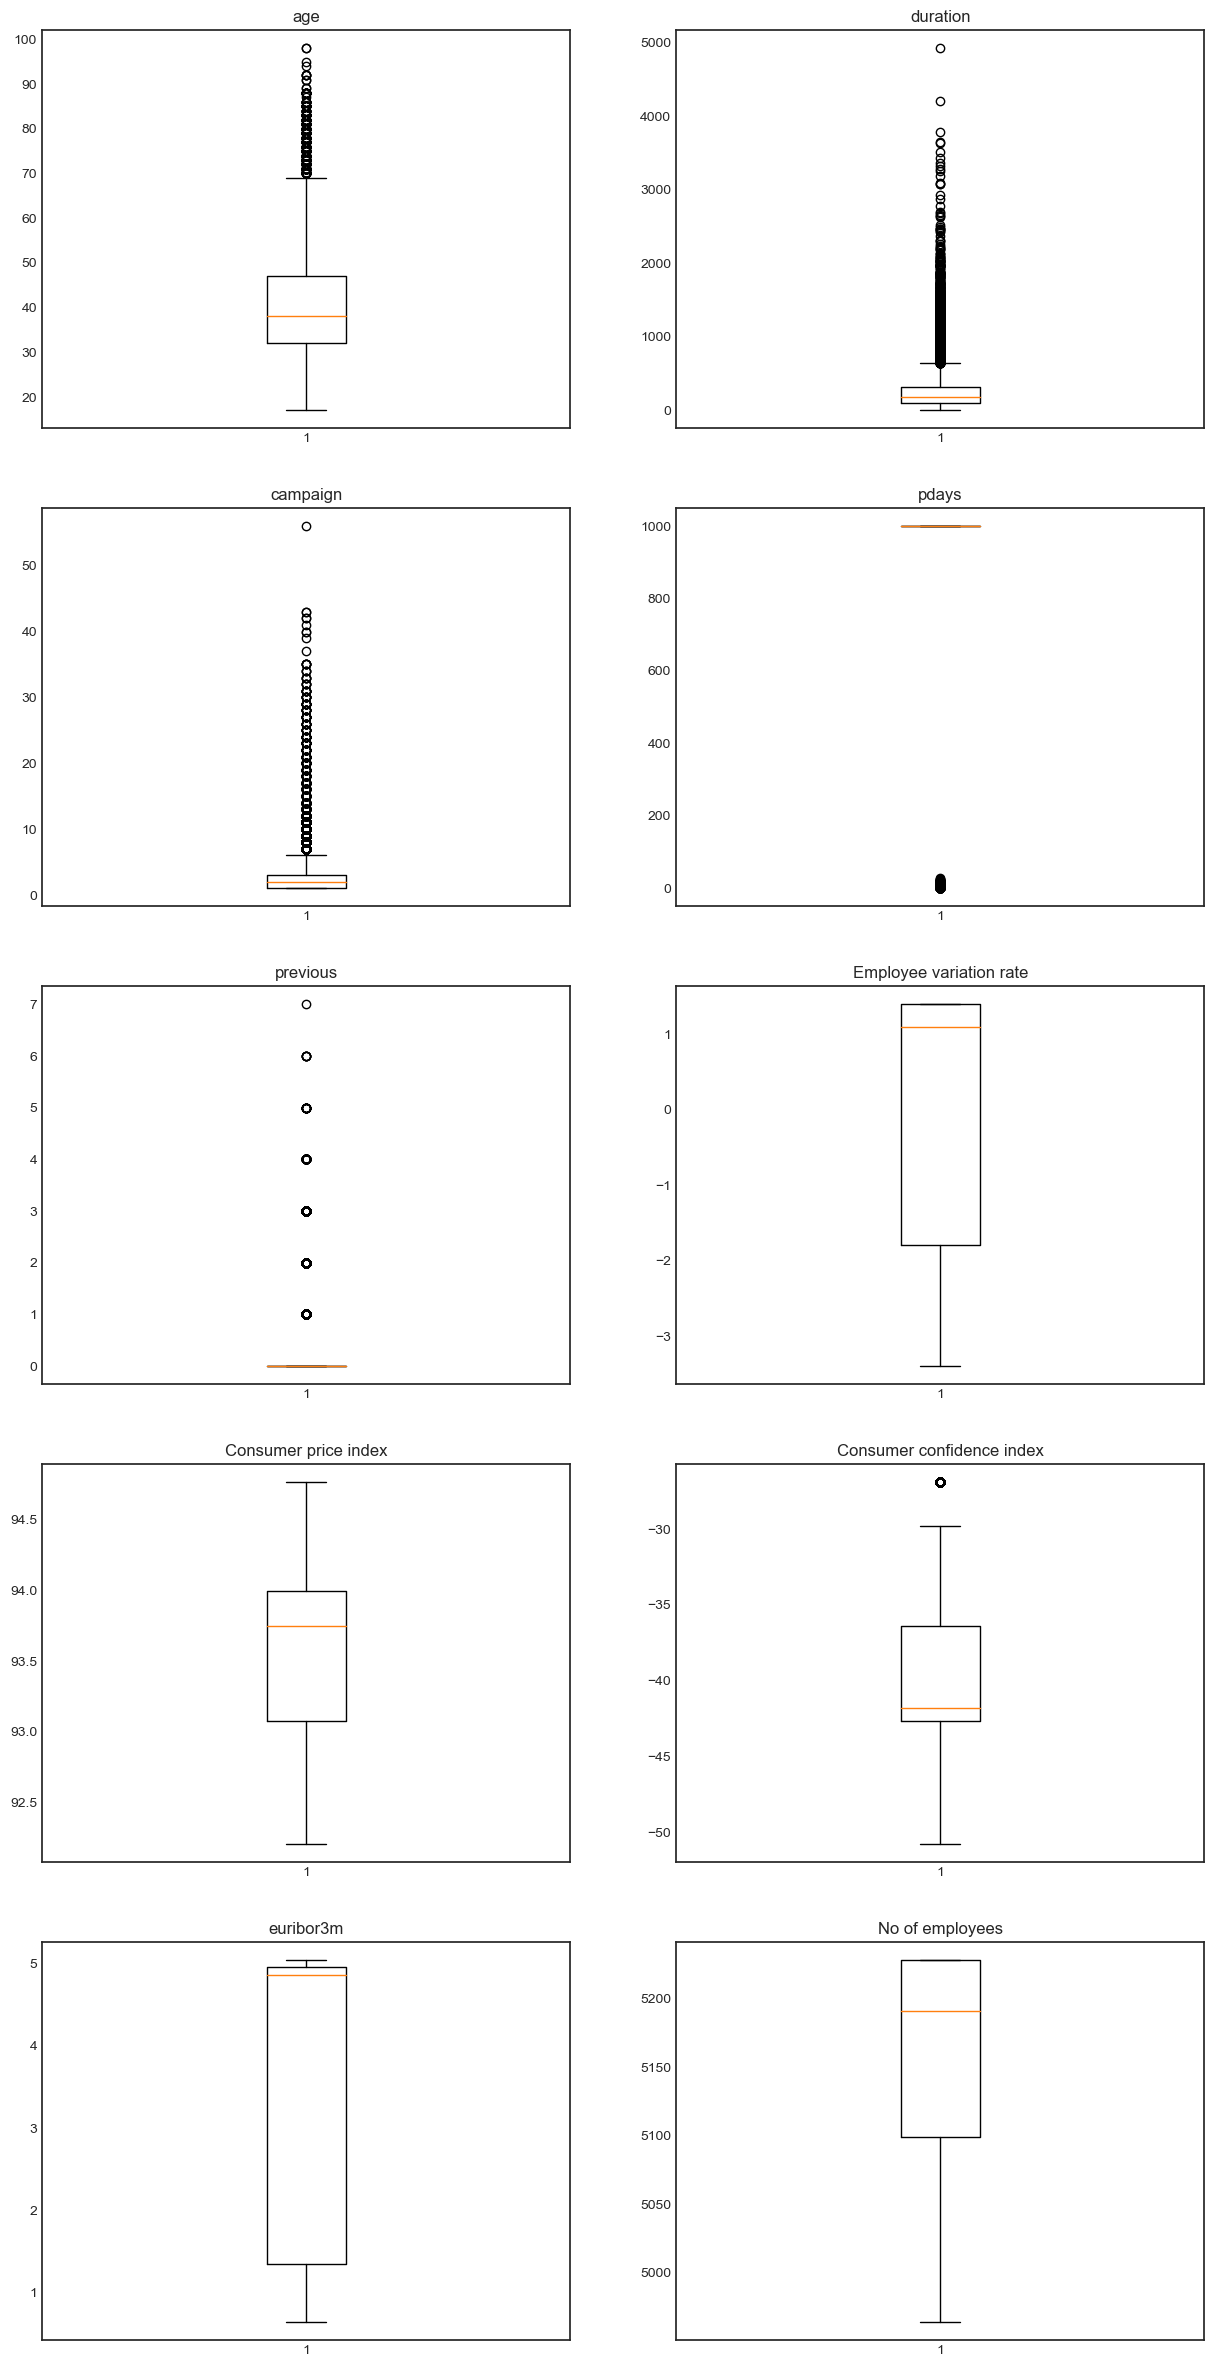

In [18]:
plt.figure(figsize = (15, 30))
plt.style.use('seaborn-white')
ax=plt.subplot(521)
plt.boxplot(df['age'])
ax.set_title('age')
ax=plt.subplot(522)
plt.boxplot(df['duration'])
ax.set_title('duration')
ax=plt.subplot(523)
plt.boxplot(df['campaign'])
ax.set_title('campaign')
ax=plt.subplot(524)
plt.boxplot(df['pdays'])
ax.set_title('pdays')
ax=plt.subplot(525)
plt.boxplot(df['previous'])
ax.set_title('previous')
ax=plt.subplot(526)
plt.boxplot(df['emp.var.rate'])
ax.set_title('Employee variation rate')
ax=plt.subplot(527)
plt.boxplot(df['cons.price.idx'])
ax.set_title('Consumer price index')
ax=plt.subplot(528)
plt.boxplot(df['cons.conf.idx'])
ax.set_title('Consumer confidence index')
ax=plt.subplot(529)
plt.boxplot(df['euribor3m'])
ax.set_title('euribor3m')
ax=plt.subplot(5,2,10)
plt.boxplot(df['nr.employed'])
ax.set_title('No of employees')

In [19]:
numerical_features=['age','campaign','duration']
for cols in numerical_features:
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1     

    filter = (df[cols] >= Q1 - 1.5 * IQR) & (df[cols] <= Q3 + 1.5 *IQR)
    df=df.loc[filter]

C:\Users\nde\AppData\Local\Temp\ipykernel_14152\282674242.py:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


Text(0.5, 1.0, 'campaign')

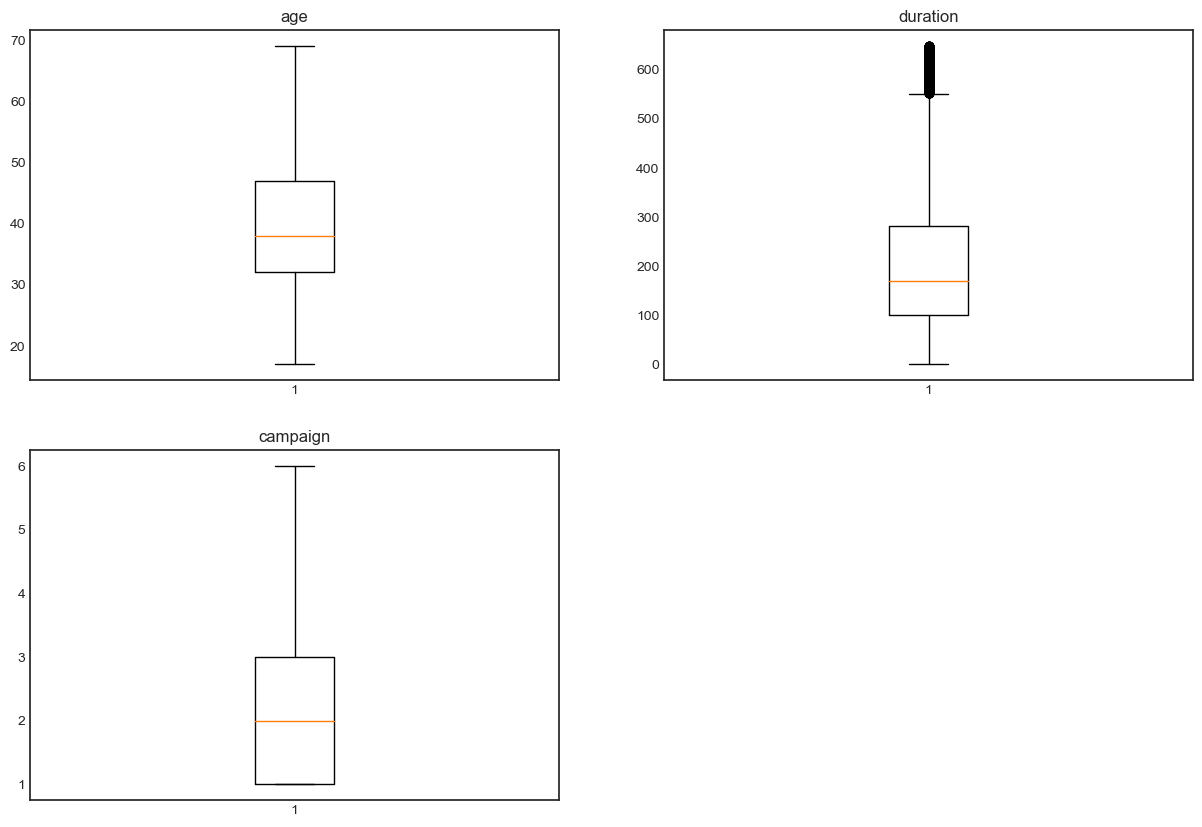

In [20]:
plt.figure(figsize = (15, 10))
plt.style.use('seaborn-white')
ax=plt.subplot(221)
plt.boxplot(df['age'])
ax.set_title('age')
ax=plt.subplot(222)
plt.boxplot(df['duration'])
ax.set_title('duration')
ax=plt.subplot(223)
plt.boxplot(df['campaign'])
ax.set_title('campaign')

In [21]:
display(df.describe(), df.describe(include=object))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000,35561.000000
mean,39.598493,207.117741,2.044234,963.564607,0.174911,0.064917,93.566352,-40.524209,3.609162,5166.677906
std,9.678582,140.527334,1.284342,184.209635,0.493206,1.567040,0.576926,4.623679,1.731402,71.417378
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4964.000000
25%,32.000000,101.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.000000
50%,38.000000,170.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000
75%,47.000000,281.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.000000
max,69.000000,648.000000,6.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.000000


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,35561,35561,35561,35561,35561,35561,35561,35561,35561,35561,35561
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,mon,nonexistent,no
freq,9110,21506,10559,28184,18671,29320,22625,12168,7494,30596,32676


# 4. Preprocessing

# 5. Methodology (Data Analytics)

>## Which customer should we target so we can improve marketing efficiency?

In [22]:
# Convert 'y' to binary (1 = yes, 0 = no)
df["y_num"] = df["y"].map({"yes": 1, "no": 0})

# Create age groups
bins = [0, 16, 25, 35, 45, 55, 65, 69, float('inf')]  
labels = ["<17", "17-25", "26-35", "36-45", "46-55", "56-65", "66-69", ">69"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)


In [23]:
# Function to calculate subscription rate & value counts
def analyze_feature(column):
    value_counts = df[column].value_counts()
    subscription_rate = df.groupby(column)["y_num"].mean()
    
    return pd.DataFrame({
        "Total Customers": value_counts,
        "Subscription Rate": subscription_rate
    }).sort_values(by="Subscription Rate", ascending=False)

# Analyze each feature
age_analysis = analyze_feature("age_group")
job_analysis = analyze_feature("job")
education_analysis = analyze_feature("education")
marital_analysis = analyze_feature("marital")

# Display results
print("Age Group Analysis:\n", age_analysis)
print("\nJob Analysis:\n", job_analysis)
print("\nEducation Analysis:\n", education_analysis)
print("\nMarital Status Analysis:\n", marital_analysis)


Age Group Analysis:
        Total Customers  Subscription Rate
66-69              132           0.439394
17-25             1435           0.186760
56-65             2592           0.130015
26-35            12990           0.087683
46-55             7188           0.061213
36-45            11224           0.057288
<17                  0                NaN
>69                  0                NaN

Job Analysis:
                Total Customers  Subscription Rate
student                    780           0.294872
retired                   1137           0.161829
unemployed                 887           0.128523
admin.                    9110           0.104830
management                2551           0.081145
technician                5892           0.080448
unknown                    279           0.075269
housemaid                  899           0.073415
self-employed             1222           0.072831
entrepreneur              1270           0.054331
services                  3456     

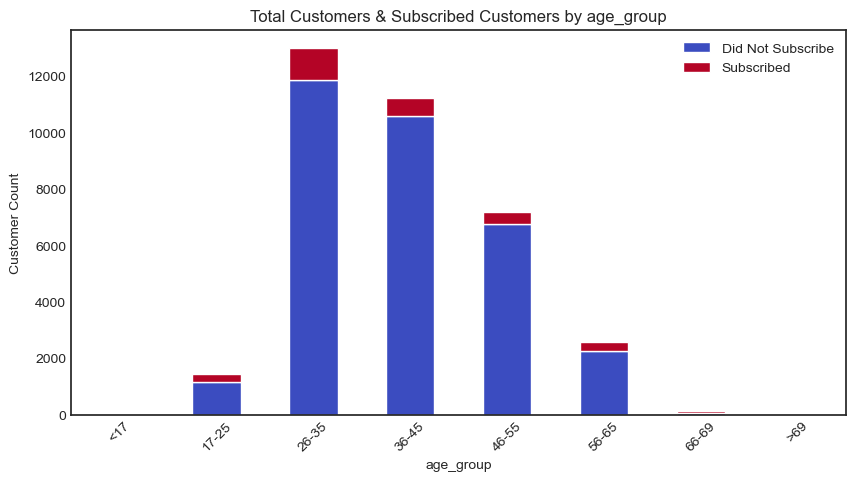

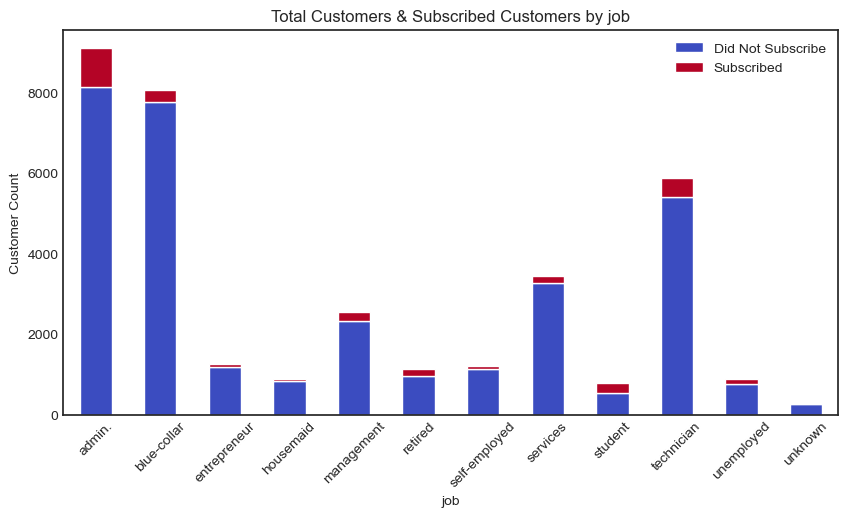

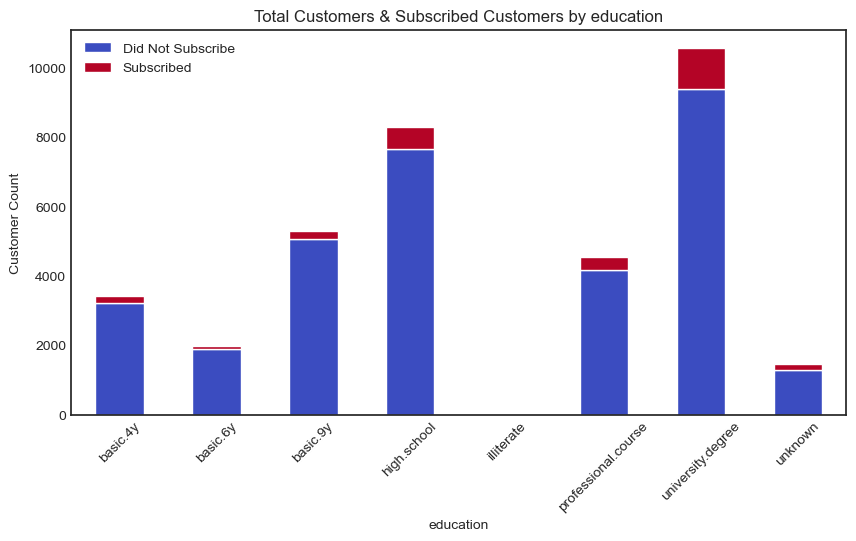

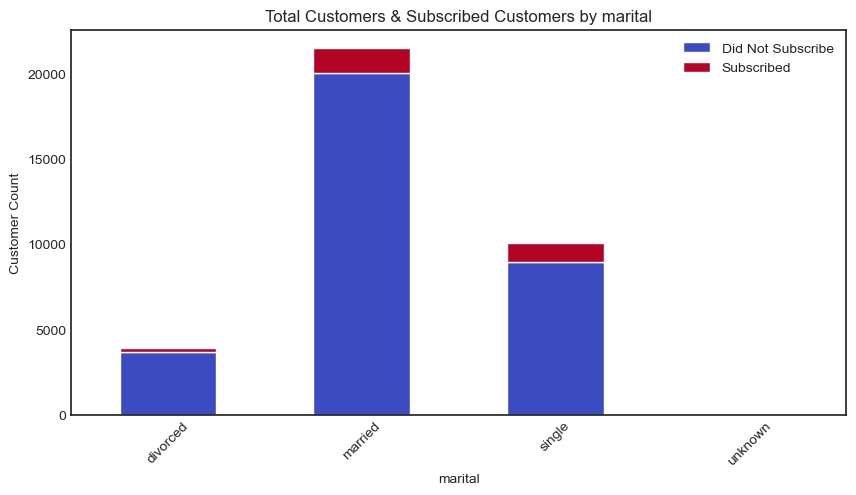

In [24]:
def plot_combined_bar(df, column):
    # Count total customers and subscribed customers
    grouped = df.pivot_table(index=column, columns="y", aggfunc="size", fill_value=0)

    # Ensure columns are named correctly
    grouped.columns = ["Did Not Subscribe", "Subscribed"]

    # Plot
    grouped.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="coolwarm")

    plt.title(f"Total Customers & Subscribed Customers by {column}")
    plt.ylabel("Customer Count")
    plt.xlabel(column)
    plt.xticks(rotation=45)
    plt.legend(["Did Not Subscribe", "Subscribed"])
    plt.show()

# Apply to features
plot_combined_bar(df, "age_group")
plot_combined_bar(df, "job")
plot_combined_bar(df, "education")
plot_combined_bar(df, "marital")


Age group analysis:
- The 26-35 and 36-45 have the highest total customer count and subscription rate, making them the primary targets for marketing. 
- The 17-25 age group has a lower total count but a visible subscription portion. 
- Older age groups (66-69, >69) have very few customers. They contribute little to total subscriptions, so they may not be a priority for marketing efforts. The 66+ groups may not be worth targeting due to low engagement.
Key takeaway: Investing more in 26-35 and 36-45 groups could be effective in increasing conversions. If marketing budgets allow, 17-25 group could be tested with targeted campaigns.

Job analysis: 
- The admin, blue-collar, and technician jobs have the highest number of customers. Among these, admin seem to have a relatively higher subscription rate.
- Students have a small total population but a relatively high subscription rate.
- Key takeaway: Admin and students could be promising targets for marketing since they show good subscription potential.

Education analysis: 
- Customers with a university degree form the largest group and have a significant number of subscriptions.
- High school graduates also form a large group and have a fair number of subscriptions.
- Key takeaway: Customers with higher education (university degree and high school graduates) seem more likely to subscribe.

Marital analysis:
- Married individuals make up the largest group but have a relatively low subscription rate.
- Singles are the second-largest group and have a much higher subscription rate.
- Key takeaway: Best target for marketing is single individuals because they have a relatively large population and a high subscription rate. Although married individual subscription rate is lower, their large population could still make them valuable with the right marketing approach.

Marketing Efficiency Recommendation
To optimize marketing efforts:
- Primary Focus: 26-35 age group, admin, students, single individuals and those with higher education (university degree & high school graduates).
- Secondary Focus: 36-45 age group, blue-collar, technician, married individuals as they have a high number of total customers.
- Avoid spending too much on older age groups (>56) or those with low education levels, as they tend to have lower subscription rates.

>## When is the best time of the year for a successful campaign to improve marketing efficiency?
(month, day of week)

## 5. Methodology (Machine Learning)